## Linear Regression
This is just a brief little implementation of linear regression by hand. I doubt this is the most robust way to do it, but the educational value of this exercise is really all I care about.
#### Math Summary
Although we can solve this type of problem using OLS and get a closed form solution, this is not the way that we obtain the weights in practice. So I implement a gradient descent based method here.
Our predictions are of the form $z=Xw+b$ where $X$ is the input matrix, $w$ is a column vector with the weights of our model and $b$ is the bias term (a scalar).
We use the MSE loss function i.e. $J = \frac{1}{2} \sum (z-y)^2$. Taking the derivative of that function w.r.t. $w$ we get $\frac{\partial J}{\partial w} = x(z-y) / n$ and 
w.r.t. $b$ we get $\frac{\partial J}{\partial b} = (z-y)/n$.
Then we update our weights based on the gradient descent rule $w_{i+1}= w_i - \alpha \partial J$ and simialarly for $b$.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
rng = np.random.default_rng(seed = 42)

In [3]:
class LinearModel():
    def __init__(self, input_dim):
        self.w = rng.random(input_dim).reshape(-1,1)
        self.b = 0
        self.loss_history = np.array([])
        
    def predict(self, X):
        return X @ self.w + self.b 
    
    def _get_MSE(self,X,Y):
        return np.sum((1/2)*(self.predict(X)-Y)**2) / len(Y)
        
    def _get_gradient_w(self,X,Y):
        return X.T @ (self.predict(X)-Y) / len(Y)
        
    def _get_gradient_b(self,X,Y):
        return np.sum((self.predict(X) - Y), axis=0) / len(Y)
        
    def train(self, X, Y, a, epochs):
        self.loss_history = np.zeros(epochs)
        for i in range(epochs):
            gradient_w = self._get_gradient_w(X,Y).reshape(-1,1)
            self.w = self.w - a * gradient_w
            gradient_b = self._get_gradient_b(X,Y).item()
            self.b = self.b - a * gradient_b
            
            self.loss_history[i] = self._get_MSE(X,Y)

In [4]:
m = 4
b = -2

X = rng.random(1000) * 10
X = X[:,np.newaxis]
print(X.shape)
noise = rng.random(1000)
noise = noise[:,np.newaxis]
Y = m * X + b + noise

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2)
model = LinearModel(1)
model.train(X_train, Y_train, 0.01, 1000)
print(model.w, model.b)



(1000, 1)
[[3.97871356]] -1.3522138878996972


The weights are pretty reasonable since our noise has a mean of $0.5$ 

Text(0.5, 1.0, 'Loss History')

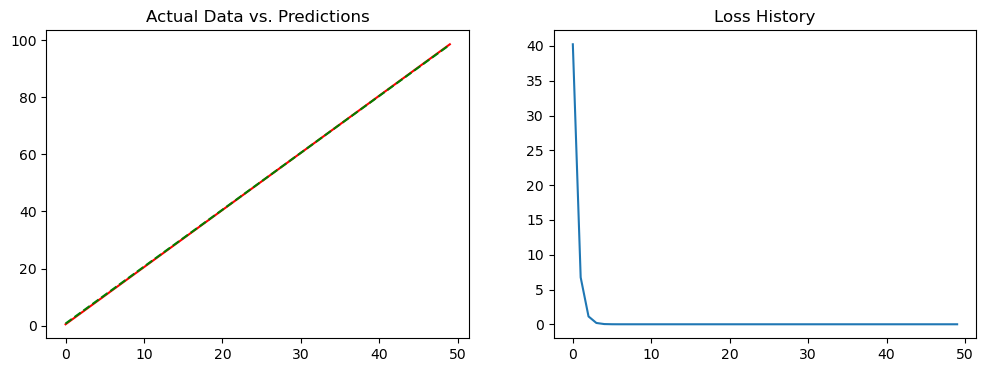

In [5]:
m = np.array([1,0])
b = 0.5

X2 = np.arange(100).reshape(50,2)
Y2 = (X2 @ m + b).reshape(-1,1)

X2_train,X2_test,Y2_train,Y2_test = train_test_split(X2,Y2, test_size=0.2)
model2 = LinearModel(2)
model2.train(X2_train,Y2_train,0.0001,50)

fig, axs = plt.subplots(1,2, figsize=(12,4))

axs[0].plot(Y2, c="red")
axs[0].plot(model2.predict(X2), linestyle="dashed", c="green")
axs[0].set_title("Actual Data vs. Predictions")
axs[1].plot(model2.loss_history)
axs[1].set_title("Loss History")

Here are my personal lessons that came from coding this up from scratch. Turns out even such seemingly trivial things are nuanced when you don't let an LLM code everything.
- Having a clear understanding of dimensions of things and planning things out is cruical. 
- Be very cognizant of when you have a 1D array vs. a 2D array that is a column or row vector e.g. (x,1) or (1,x)
- Probably good to have a grasp of what the math looks like before trying to code things